В начале скачаем демонстрационное видео и выполним декодирование в последовательность кадров.

In [3]:
import os
import cv2

for name in ['output.mp4', 'input.mp4']:
    if os.path.exists(name):
        cap = cv2.VideoCapture(name)
        fps = cap.get(cv2.CAP_PROP_FPS)
        frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        cap.release()
        print(f'\n{name}: {w}x{h}, {fps} FPS, {frames} кадров')



output.mp4: 1920x1080, 30.0 FPS, 301 кадров

input.mp4: 1920x1080, 30.0 FPS, 301 кадров


In [4]:
def extract_frames(video_path: str, save_dir: str, max_frames: int = None) -> int:
    os.makedirs(save_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if max_frames and count >= max_frames:
            break
        cv2.imwrite(f'{save_dir}/frame_{count:05d}.jpg', frame,
                    [cv2.IMWRITE_JPEG_QUALITY, 95])
        count += 1
    cap.release()
    return count


n_out = extract_frames('output.mp4', 'frames_output')
print(f'{n_out} кадров сохранено в frames_output/')

n_in = extract_frames('input.mp4', 'frames_input')
print(f'{n_in} кадров сохранено в frames_input/')


301 кадров сохранено в frames_output/
301 кадров сохранено в frames_input/


Посмотрим и сравним визуально кадры из frames_output и frames_input

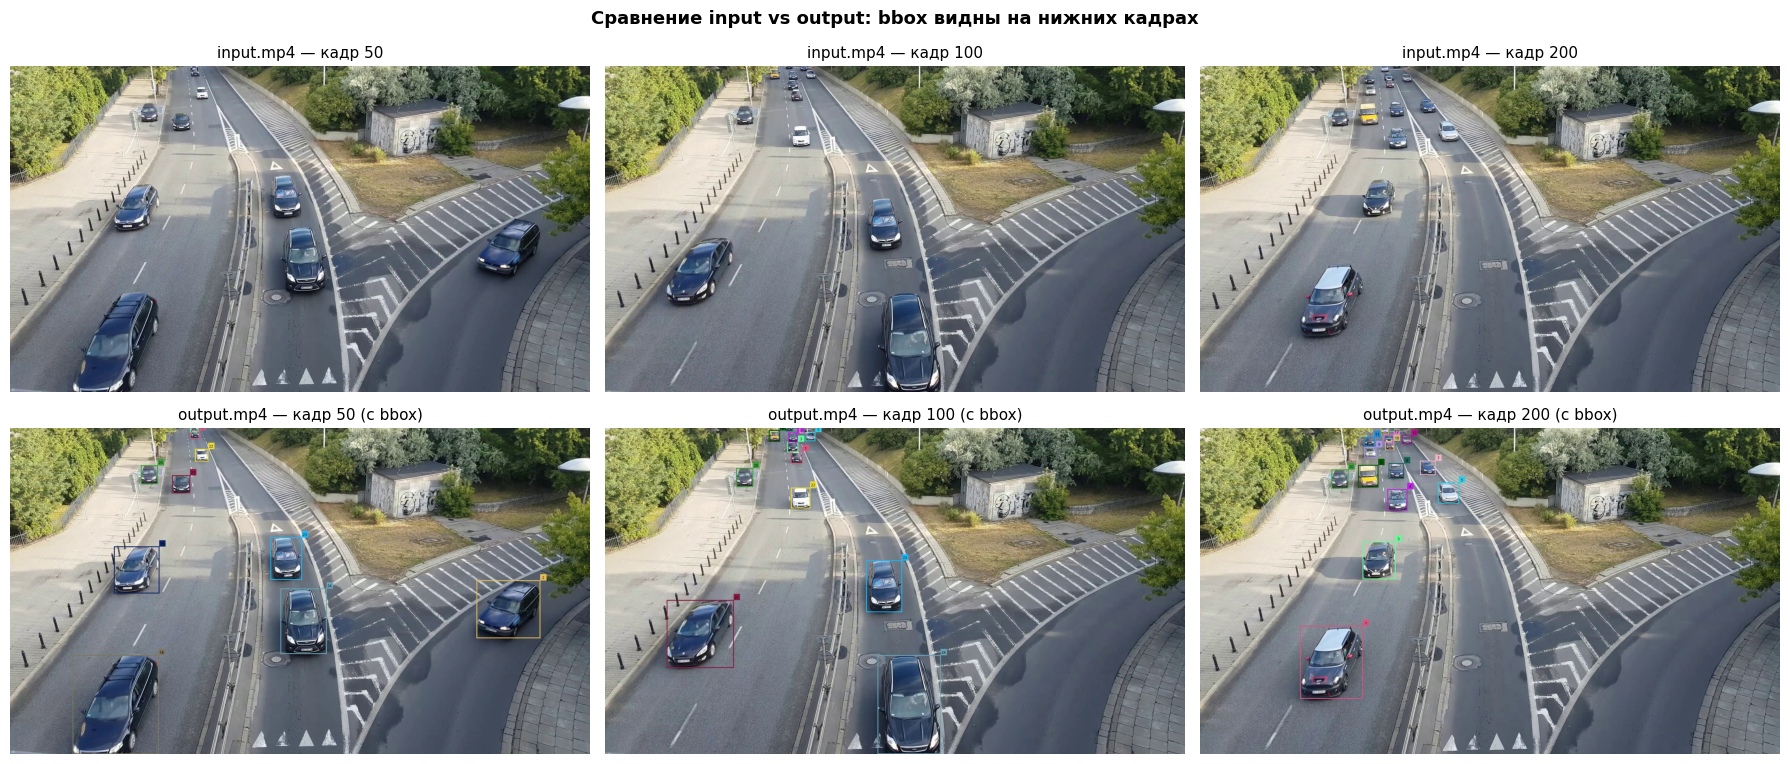

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
sample_frames = [50, 100, 200]

for col, fnum in enumerate(sample_frames):
    img_in  = cv2.imread(f'frames_input/frame_{fnum:05d}.jpg')
    img_out = cv2.imread(f'frames_output/frame_{fnum:05d}.jpg')
    
    axes[0, col].imshow(cv2.cvtColor(img_in, cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(f'input.mp4 — кадр {fnum}', fontsize=11)
    axes[0, col].axis('off')
    
    axes[1, col].imshow(cv2.cvtColor(img_out, cv2.COLOR_BGR2RGB))
    axes[1, col].set_title(f'output.mp4 — кадр {fnum} (с bbox)', fontsize=11)
    axes[1, col].axis('off')

plt.suptitle('Сравнение input vs output: bbox видны на нижних кадрах', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_frames.png', dpi=100, bbox_inches='tight')
plt.show()

Попробуем несколько методов нахождения bbox - метод Canny (детектор границ) и метод глобальной бинаризации, затем сравним их результаты по IoU

In [6]:
def extract_bboxes_canny(in_frame_path, out_frame_path):
    img_in, img_out = cv2.imread(in_frame_path), cv2.imread(out_frame_path)
    if img_in is None or img_out is None:
        return []

    diff = cv2.absdiff(img_in, img_out)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    dilated = cv2.dilate(edges, np.ones((5, 5), np.uint8), iterations=1)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bboxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w > 20 and h > 20:
            bboxes.append([x, y, x + w, y + h])
    return bboxes


def extract_bboxes_binary(in_frame_path, out_frame_path):
    img_in, img_out = cv2.imread(in_frame_path), cv2.imread(out_frame_path)
    if img_in is None or img_out is None:
        return []

    diff = cv2.absdiff(img_in, img_out)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bboxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w > 20 and h > 20:
            bboxes.append([x, y, x + w, y + h])
    return bboxes

  Кадр 0


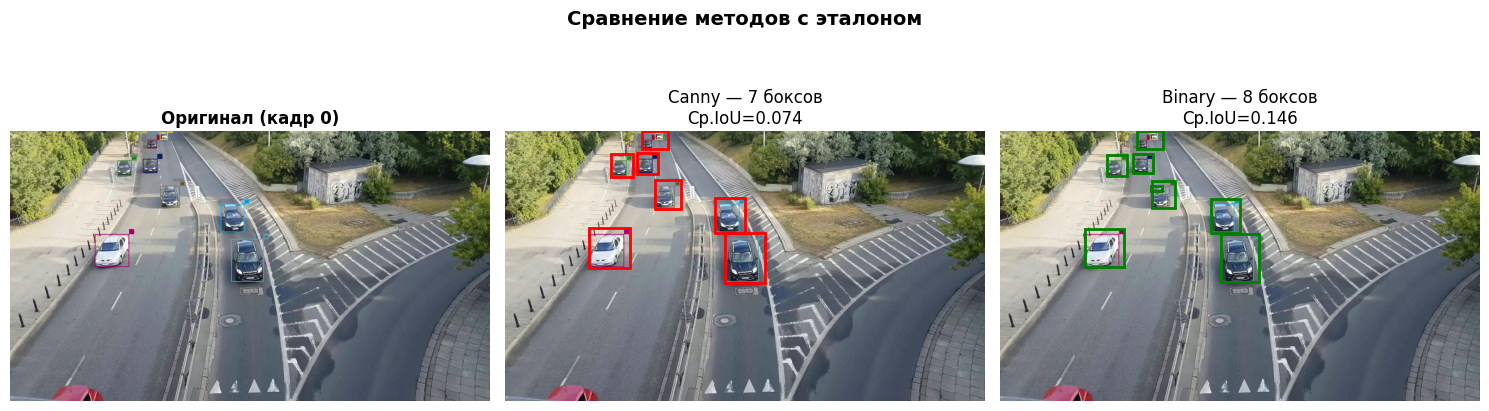

  Кадр 75


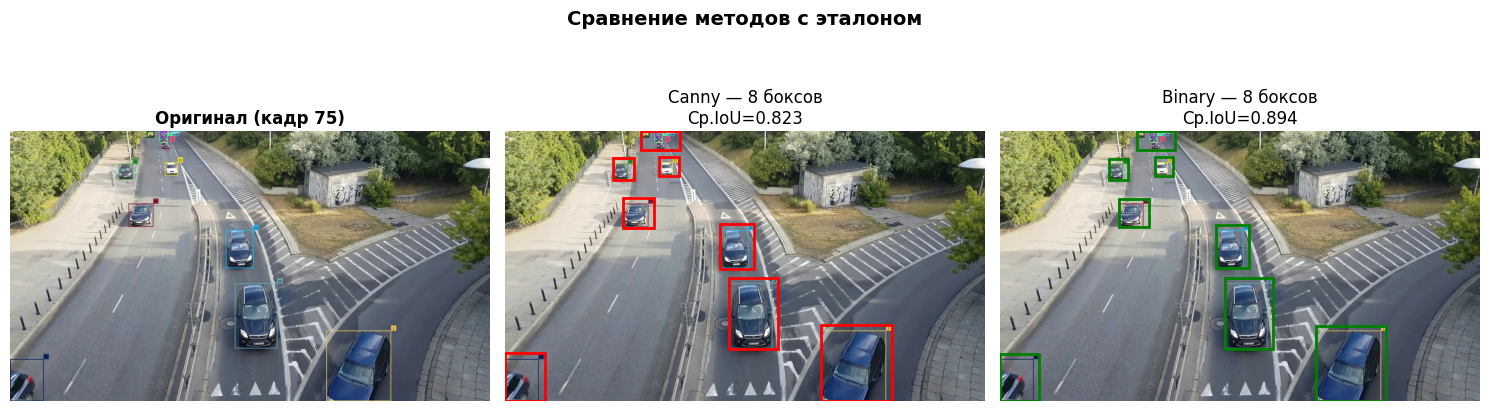

  Кадр 150


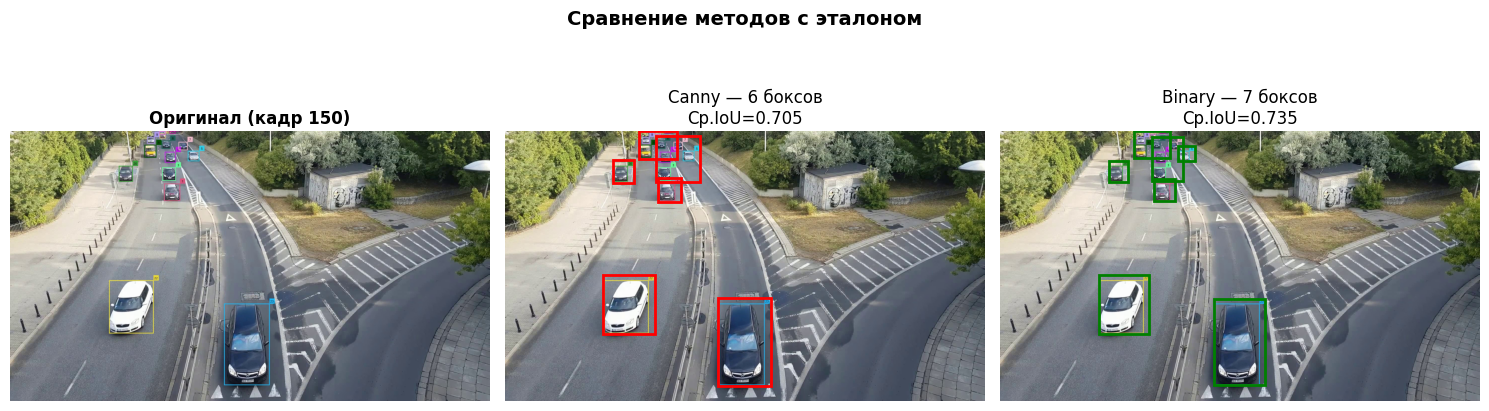

  Кадр 225


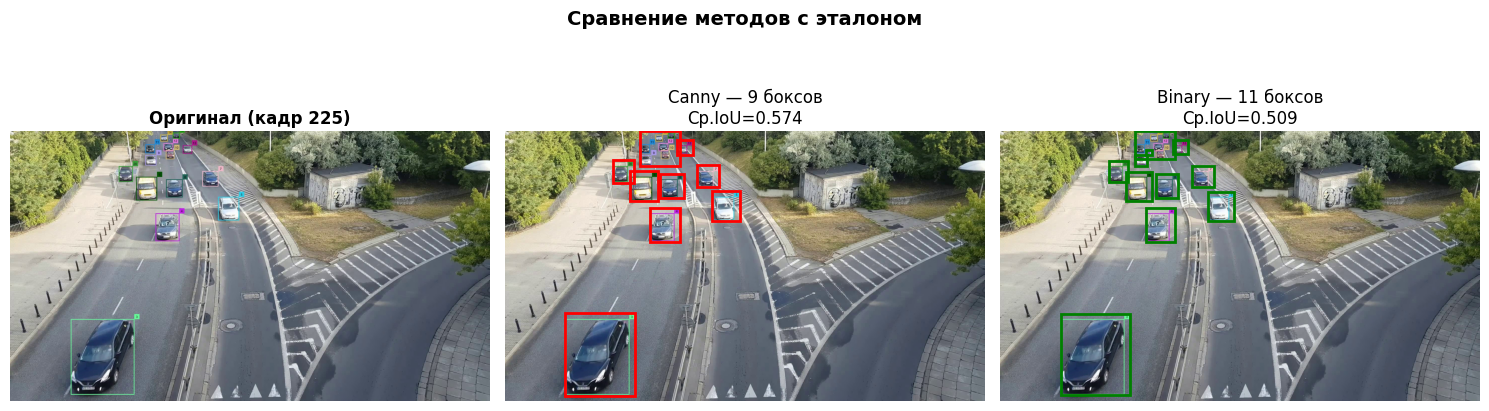

  Кадр 300


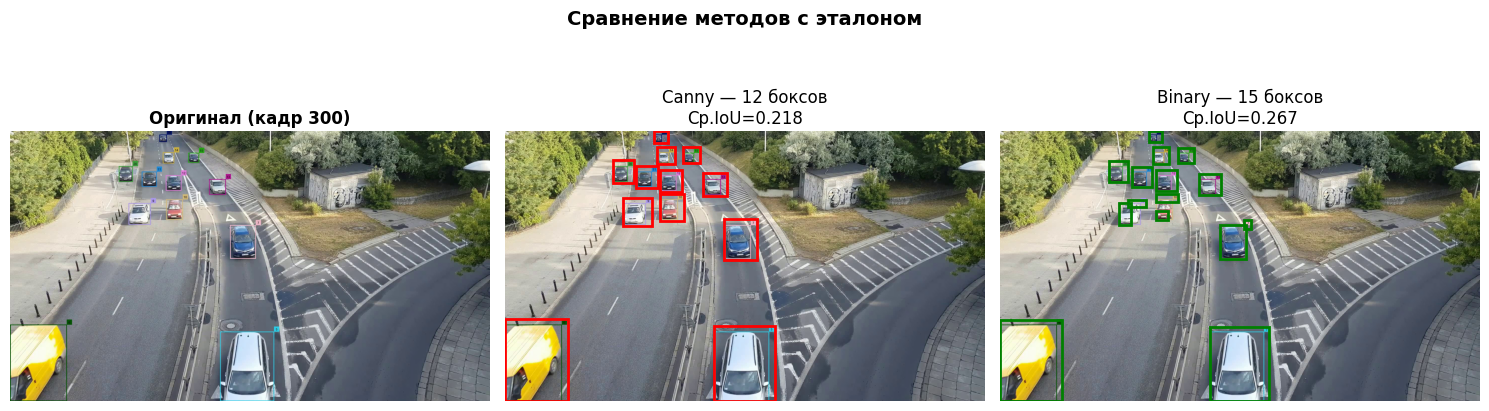


Статистика по всем 301 кадрам:
  Средний IoU   — Canny: 0.356  |  Binary: 0.457
  Медианный IoU — Canny: 0.375  |  Binary: 0.470


In [21]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import glob

def iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    return intersection / union if union > 0 else 0

def extract_bboxes_from_diff(in_frame_path, out_frame_path):
    img_in = cv2.imread(in_frame_path)
    img_out = cv2.imread(out_frame_path)
    diff = cv2.absdiff(img_in, img_out)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bboxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w > 20 and h > 20:
            bboxes.append([x, y, x + w, y + h])
    return bboxes

def compute_avg_iou(boxes_pred, boxes_gt):
    ious = []
    for i in range(min(len(boxes_pred), len(boxes_gt))):
        ious.append(iou(boxes_pred[i], boxes_gt[i]))
    return np.mean(ious) if ious else 0

def get_all_frame_numbers(folder='frames_input'):
    paths = glob.glob(os.path.join(folder, 'frame_*.jpg'))
    numbers = []
    for p in paths:
        basename = os.path.basename(p)
        num_str = basename.replace('frame_', '').replace('.jpg', '')
        try:
            numbers.append(int(num_str))
        except ValueError:
            pass
    return sorted(numbers)

def compute_iou_for_frame(frame_number):
    in_path = f'frames_input/frame_{frame_number:05d}.jpg'
    out_path = f'frames_output/frame_{frame_number:05d}.jpg'

    if not os.path.exists(in_path) or not os.path.exists(out_path):
        return None, None

    boxes_gt = extract_bboxes_from_diff(in_path, out_path)
    boxes_canny = extract_bboxes_canny(in_path, out_path)
    boxes_binary = extract_bboxes_binary(in_path, out_path)

    return compute_avg_iou(boxes_canny, boxes_gt), compute_avg_iou(boxes_binary, boxes_gt)

def visualize_frame(frame_number):
    in_path = f'frames_input/frame_{frame_number:05d}.jpg'
    out_path = f'frames_output/frame_{frame_number:05d}.jpg'

    boxes_gt = extract_bboxes_from_diff(in_path, out_path)
    boxes_canny = extract_bboxes_canny(in_path, out_path)
    boxes_binary = extract_bboxes_binary(in_path, out_path)

    avg_iou_canny = compute_avg_iou(boxes_canny, boxes_gt)
    avg_iou_binary = compute_avg_iou(boxes_binary, boxes_gt)

    img = cv2.cvtColor(cv2.imread(out_path), cv2.COLOR_BGR2RGB)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img)
    axes[0].set_title(f'Оригинал (кадр {frame_number})', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(img)
    for box in boxes_canny:
        rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                  linewidth=2, edgecolor='red', facecolor='none')
        axes[1].add_patch(rect)
    axes[1].set_title(f'Canny — {len(boxes_canny)} боксов\nСр.IoU={avg_iou_canny:.3f}', fontsize=12)
    axes[1].axis('off')

    axes[2].imshow(img)
    for box in boxes_binary:
        rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                  linewidth=2, edgecolor='green', facecolor='none')
        axes[2].add_patch(rect)
    axes[2].set_title(f'Binary — {len(boxes_binary)} боксов\nСр.IoU={avg_iou_binary:.3f}', fontsize=12)
    axes[2].axis('off')

    plt.suptitle('Сравнение методов с эталоном', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'comparison_frame_{frame_number}.png', dpi=150, bbox_inches='tight')
    plt.show()


all_frame_numbers = get_all_frame_numbers('frames_input')


all_ious_canny, all_ious_binary = [], []
for frame in all_frame_numbers:
    iou_c, iou_b = compute_iou_for_frame(frame)
    if iou_c is not None:
        all_ious_canny.append(iou_c)
        all_ious_binary.append(iou_b)

vis_frames = [0, 75, 150, 225, 300]

for frame in vis_frames:
    print(f"  Кадр {frame}")
    visualize_frame(frame)

print(f"\n{'='*50}")
print(f"Статистика по всем {len(all_ious_canny)} кадрам:")
print(f"  Средний IoU   — Canny: {np.mean(all_ious_canny):.3f}  |  Binary: {np.mean(all_ious_binary):.3f}")
print(f"  Медианный IoU — Canny: {np.median(all_ious_canny):.3f}  |  Binary: {np.median(all_ious_binary):.3f}")

IoU - метрика, используемая для оценки точности работы алгоритмов обнуружения объектов, чем больше её показатель, тем лучше результат. Метод Binary имеет большее значение, значит он лушче справился со своей задачей

Сформируем структурированный датасет с аннотациями в формате COCO

In [30]:
import json
def create_coco_dataset(input_dir, output_dir, limit=None):
    coco_format = {
        "images": [],
        "annotations": [],
        "categories": [{"id": 1, "name": "car"}],
    }
    annotation_id = 1
    frames = sorted(os.listdir(input_dir))
    if limit:
        frames = frames[:limit]

    for img_id, frame_name in enumerate(frames):
        in_path = os.path.join(input_dir, frame_name)
        out_path = os.path.join(output_dir, frame_name)

        img = cv2.imread(in_path)
        if img is None:
            continue
        h, w, _ = img.shape

        coco_format["images"].append(
            {"id": img_id, "file_name": frame_name, "width": w, "height": h}
        )
        bboxes = extract_bboxes_binary(in_path, out_path) 
        for box in bboxes:
            xmin, ymin, xmax, ymax = box
            width = xmax - xmin
            height = ymax - ymin
            area = width * height

            coco_format["annotations"].append(
                {
                    "id": annotation_id,
                    "image_id": img_id,
                    "category_id": 1,
                    "bbox": [xmin, ymin, width, height],
                    "area": area,
                    "iscrowd": 0,
                }
            )
            annotation_id += 1

    with open("annotations.json", "w") as f:
        json.dump(coco_format, f, indent=4)

create_coco_dataset("frames_input", "frames_output")

Обучим детектор объектов на основе готовой архитектуры из torchvision.models.detection - Faster R-CNN, применим метод early stopping против переобучения и представим графики потерь. 

P.S. На данном этапе вычислительные средства моего ноутбука отказались обучать модель в адекватные сроки, поэтому я стала работать в Google Colab - дальнейшие результаты работы кода можно увидеть перейдя по ссылке из README. Дальнейший код здесь полностью повторяет код там, однако тут не отображаются результаты его выполнения

In [ ]:
import json
import os
import cv2
import numpy as np
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib.pyplot as plt

class CarDataset(Dataset):
    def __init__(self, root_dir, annotation_file):
        self.root_dir = root_dir
        with open(annotation_file, "r") as f:
            self.coco = json.load(f)

        self.images = self.coco["images"]
        self.annotations = self.coco["annotations"]

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = os.path.join(self.root_dir, img_info["file_name"])

        img = cv2.imread(img_path)

        orig_h, orig_w = img.shape[:2]
        target_width = 420
        scale_ratio = target_width / orig_w
        target_height = int(orig_h * scale_ratio)

        img = cv2.resize(img, (target_width, target_height))

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        img = torch.tensor(img).permute(2, 0, 1)

        image_annots = [
            ann for ann in self.annotations if ann["image_id"] == img_info["id"]
        ]

        boxes = []
        labels = []
        for ann in image_annots:
            x, y, w, h = ann["bbox"]
            xmin = x * scale_ratio
            ymin = y * scale_ratio
            xmax = (x + w) * scale_ratio
            ymax = (y + h) * scale_ratio

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(ann["category_id"])

        target = {}
        target["boxes"] = (
            torch.tensor(boxes, dtype=torch.float32)
            if len(boxes) > 0
            else torch.zeros((0, 4), dtype=torch.float32)
        )
        target["labels"] = torch.tensor(labels, dtype=torch.int64)
        target["image_id"] = torch.tensor([img_info["id"]])

        return img, target

    def __len__(self):
        return len(self.images)

def get_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def collate_fn(batch):
    return tuple(zip(*batch))

FRAMES_IN_DIR = "frames_input" 
COCO_ANNOTATIONS_PATH = "annotations.json"
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

print("Инициализация данных...")
dataset = CarDataset(FRAMES_IN_DIR, COCO_ANNOTATIONS_PATH)

# Разбиение на Train (0.8) и Val (0.2)
torch.manual_seed(42)
indices = torch.randperm(len(dataset)).tolist()
val_size = int(len(dataset) * 0.2)
dataset_train = torch.utils.data.Subset(dataset, indices[:-val_size])
dataset_val = torch.utils.data.Subset(dataset, indices[-val_size:])

train_loader = DataLoader(dataset_train, batch_size=1, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(dataset_val, batch_size=1, shuffle=False, collate_fn=collate_fn)

model = get_model(num_classes=2).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

epochs = 10
train_losses = []

best_loss = float("inf")
patience = 3
patience_counter = 0

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    for images, targets in train_loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    avg_epoch_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_epoch_loss)
    print(f"Эпоха {epoch + 1}/{epochs}, Loss: {avg_epoch_loss:.4f}")

    torch.cuda.empty_cache()
    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Останавливаем обучение т.к. сработал early stopping.")
            break

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    marker="o",
    color="b",
    label="Training Loss",
)

plt.title("График потерь (Loss) при обучении")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Инициализация данных...


KeyboardInterrupt: 

In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
metric = MeanAveragePrecision(iou_type="bbox")

if os.path.exists("best_model.pth"):
    model.load_state_dict(torch.load("best_model.pth", weights_only=True))

model.eval()
with torch.no_grad():
    for images, targets in val_loader:
        images = list(img.to(device) for img in images)
        outputs = model(images)

        preds = []
        for out in outputs:
            preds.append(
                {
                    "boxes": out["boxes"].cpu(),
                    "scores": out["scores"].cpu(),
                    "labels": out["labels"].cpu(),
                }
            )
        targs = []
        for t in targets:
            targs.append({"boxes": t["boxes"], "labels": t["labels"]})

        metric.update(preds, targs)

results = metric.compute()
print(f"mAP (IoU 0.50-0.95): {results['map'].item()}")
print(f"mAP@50: {results['map_50'].item()}")
print(f"mAP@75: {results['map_75'].item()}")

mAP показывает, насколько хорошо модель находит объекты и правильно определяет их границы. mAP@50 считает предсказание правильным, если IoU >= 0.5, mAP@75 если IoU >= 0.75, mAP (IoU 0.50-0.95) усреденяет mAP по разным IoU. 

mAP (IoU 0.50-0.95) = 0.87, mAP@50 = 0.96, mAP@75 = 0.91 Это означает, что модель достаточно точно определяет границы объектов. При увеличении строгости IoU модель показывает чуть более низкие результаты, что скорее всего связано с распознаванием скопления автомобилей вдали. 

Провизуализируем работу модели и сравним с эталонным распознаванием объектов

In [ ]:
import os
import xml.etree.ElementTree as ET
import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np

def calculate_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    if interArea == 0:
        return 0.0

    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    return interArea / float(boxAArea + boxBArea - interArea)

def get_max_iou(pred_box, gt_boxes):
    max_iou = 0.0
    for gt_box in gt_boxes:
        current_iou = calculate_iou(pred_box, gt_box)
        if current_iou > max_iou:
            max_iou = current_iou
    return max_iou

def get_real_boxes_from_xml(xml_path, frame_number):
    if not os.path.exists(xml_path):
        return []

    tree = ET.parse(xml_path)
    root = tree.getroot()
    real_boxes = []

    for track in root.findall("track"):
        if track.get("label") == "car":
            box = track.find(f".//box[@frame='{frame_number}']")
            if box is not None:
                real_boxes.append(
                    [
                        float(box.get("xtl")),
                        float(box.get("ytl")),
                        float(box.get("xbr")),
                        float(box.get("ybr")),
                    ]
                )

    if not real_boxes:
        for obj in root.findall("object"):
            if obj.find("name").text == "car":
                bbox = obj.find("bndbox")
                real_boxes.append(
                    [
                        float(bbox.find("xmin").text),
                        float(bbox.find("ymin").text),
                        float(bbox.find("xmax").text),
                        float(bbox.find("ymax").text),
                    ]
                )
    return real_boxes

def visualize_predictions(image_np, pred_boxes, gt_boxes=None, frame_idx=None):
    fig, ax = plt.subplots(1, figsize=(12, 9))
    ax.imshow(image_np)

    for i, box in enumerate(pred_boxes):
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(xmin, ymin - 5, "Car", color='red', fontsize=9, weight='bold', 
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    if gt_boxes is not None:
        for box in gt_boxes:
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                linewidth=2,
                edgecolor="green",
                facecolor="none",
                linestyle="--",
            )
            ax.add_patch(rect)

    ax.axis("off")
    title = f"Кадр {frame_idx}"
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

test_frame_indices = [50, 200, 250] 
FRAMES_IN_DIR = "frames_input"
FRAMES_OUT_DIR = "frames_output"
all_ious = []
all_results = []

for test_frame_idx in test_frame_indices:
    frame_path = os.path.join(FRAMES_IN_DIR, f"frame_{test_frame_idx:05d}.jpg")  
    annotated_path = os.path.join(FRAMES_OUT_DIR, f"frame_{test_frame_idx:05d}.jpg")
    xml_path = "annotations.xml"
    
    if not os.path.exists(frame_path):
        print(f"Кадр {test_frame_idx} не найден, пропускаем")
        continue
    
    image_bgr = cv2.imread(frame_path)
    if image_bgr is None:
        print(f"Не удалось прочитать кадр {test_frame_idx}")
        continue
        
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    extracted_boxes = extract_bboxes_binary(frame_path, annotated_path)
    true_boxes = get_real_boxes_from_xml(xml_path, test_frame_idx)
    visualize_predictions(image_rgb, pred_boxes=extracted_boxes, gt_boxes=true_boxes, frame_idx=test_frame_idx)
    
    if true_boxes and extracted_boxes:
        ious = [get_max_iou(b, true_boxes) for b in extracted_boxes]
        avg_iou = sum(ious) / len(ious)
        all_ious.extend(ious)
        
        result = {
            'frame': test_frame_idx,
            'detected': len(extracted_boxes),
            'ground_truth': len(true_boxes),
            'avg_iou': avg_iou,
            'max_iou': max(ious)
        }
        all_results.append(result)
        
        print(f"Кадр {test_frame_idx}:")
        print(f"  Найдено объектов (красные рамки): {len(extracted_boxes)}")
        print(f"  Эталонных объектов (зеленые рамки): {len(true_boxes)}")
        print(f"  Средний IoU по всем найденным машинам: {avg_iou:.4f}")
        print(f"  Максимальный IoU на кадре: {max(ious):.4f}")
    elif not true_boxes:
        print(f"\nКадр {test_frame_idx}: Нет эталонных объектов")
    elif not extracted_boxes:
        print(f"\nКадр {test_frame_idx}: Не найдено объектов детекции")

if all_ious:
    print(f"  Всего проанализировано кадров: {len(all_results)}")
    print(f"  Всего объектов (на всех кадрах): {len(all_ious)}")
    print(f"  Средний IoU по всем объектам: {np.mean(all_ious):.4f}")
    print(f"  Медианный IoU по всем объектам: {np.median(all_ious):.4f}")
    print(f"  Стандартное отклонение IoU: {np.std(all_ious):.4f}")
    print(f"  Минимальный IoU: {min(all_ious):.4f}")
    print(f"  Максимальный IoU: {max(all_ious):.4f}")
    

Создадим итоговый видеоролик с созданными bbox

In [ ]:
def create_result_video(input_frames_dir, annotated_frames_dir, output_video_path):
    frames = sorted(os.listdir(input_frames_dir))
    first_frame = cv2.imread(os.path.join(input_frames_dir, frames[0]))
    h, w, _ = first_frame.shape
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    fps = 30.0
    out_video = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))

    for frame_name in frames:
        in_path = os.path.join(input_frames_dir, frame_name)
        ann_path = os.path.join(annotated_frames_dir, frame_name)

        img = cv2.imread(in_path)
        bboxes = extract_bboxes_binary(in_path, ann_path)
        for i, box in enumerate(bboxes):
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
            cv2.putText(img, "Car", (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
        out_video.write(img)
    out_video.release()
    print(f"Видео сохранено")

create_result_video("frames_input", "frames_output", os.path.join("result.mp4"))